In [1]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import liana as li
from liana.method import cellphonedb, cellchat
from tqdm import tqdm
#liana dotplot returns a ggsave object...
from plotnine import ggsave, ggplot

In [2]:
adata = sc.read_h5ad("ProcessedData/"+"GF_HF"+"_CellChat.h5ad")

## make sure the version of liana is what it should be

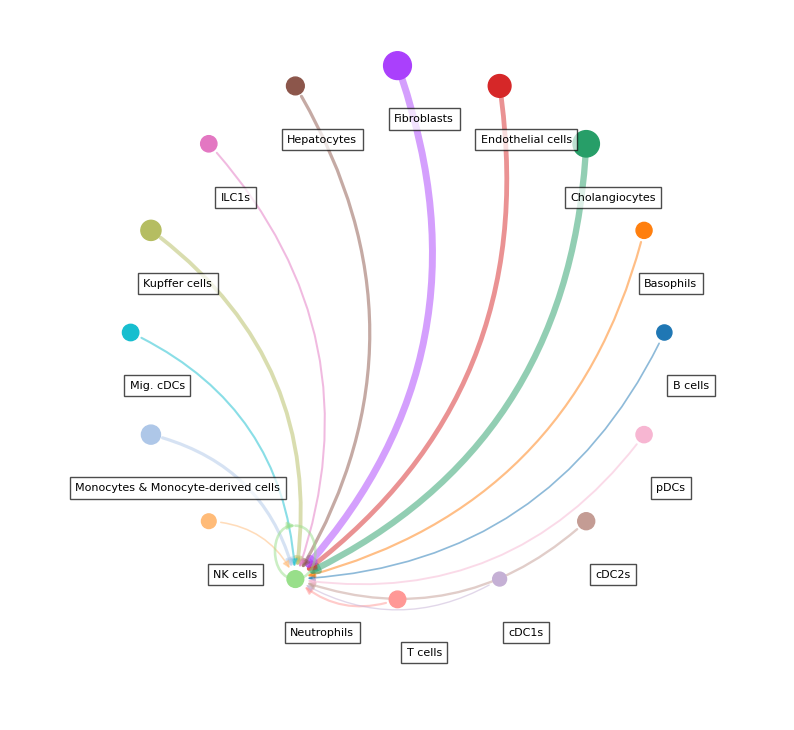

In [3]:
#make sure the version of liana is what it should be
circle_plot_test = li.pl.circle_plot(adata = adata,
                      uns_key='cpdb_res',
                      groupby='predicted_labels',
                      score_key='lr_probs',
                      inverse_score=True,
                      target_labels='Neutrophils',
                      figure_size=(10, 10)
                      )

## check if the L and R is in resource

In [4]:

resource = li.rs.select_resource('mouseconsensus')
resource.head()

,ligand,receptor
31371,Dll1,Notch1
31372,Dll1,Notch2
31373,Dll1,Notch4
31374,Dll1,Notch3
31375,Nrg2,Erbb2_Erbb3


In [5]:
y = sorted(resource.ligand.unique())

In [6]:
y

['A2m',
 'Aanat',
 'Ace',
 'Actr2',
 'Ada',
 'Adam10',
 'Adam11',
 'Adam12',
 'Adam15',
 'Adam17',
 'Adam2',
 'Adam23',
 'Adam28',
 'Adam29',
 'Adam7',
 'Adam9',
 'Adamts3',
 'Adcyap1',
 'Adipoq',
 'Adm',
 'Adm2',
 'Ado',
 'Agrn',
 'Agrp',
 'Agt',
 'Ahsg',
 'Aimp1',
 'Alb',
 'Alcam',
 'Ambn',
 'Amelx',
 'Amh',
 'Ang',
 'Angpt1',
 'Angpt2',
 'Angpt4',
 'Angptl1',
 'Angptl2',
 'Angptl3',
 'Angptl4',
 'Angptl7',
 'Anxa1',
 'Anxa2',
 'Apln',
 'Apoa1',
 'Apoa2',
 'Apoa4',
 'Apob',
 'Apoc2',
 'Apoc4',
 'Apod',
 'Apoe',
 'Apoo',
 'App',
 'Areg',
 'Arf1',
 'Arf6',
 'Arpc5',
 'Artn',
 'Avp',
 'Azgp1',
 'B2m',
 'Bcan',
 'Bdnf',
 'Bgn',
 'Bmp1',
 'Bmp10',
 'Bmp15',
 'Bmp2',
 'Bmp3',
 'Bmp4',
 'Bmp5',
 'Bmp6',
 'Bmp7',
 'Bmp8a',
 'Bpi',
 'Bsg',
 'Bst1',
 'Btc',
 'Btla',
 'Btn1a1',
 'C1qa',
 'C1qb',
 'C1qtnf1',
 'C1qtnf5',
 'C3',
 'C4a',
 'C4b',
 'C920025E04Rik',
 'Cadm1',
 'Cadm3',
 'Calca',
 'Calml3',
 'Calr',
 'Camp',
 'Cck',
 'Ccl1',
 'Ccl11',
 'Ccl12',
 'Ccl17',
 'Ccl2',
 'Ccl20',
 'Ccl21b',
 

Name of the MHCII pathway exist in resource: 'H2-Aa', 'H2-Ab1' (ligand); 

In [7]:
resource[resource.ligand == "H2-Aa"]

,ligand,receptor
31439,H2-Aa,Cd4
31440,H2-Aa,Lag3


In [8]:
resource[resource.ligand == "H2-Ab1"]

,ligand,receptor
31441,H2-Ab1,Cd4
31442,H2-Ab1,Lag3


## check if this is present in Cellchat prediction

In [9]:
x = adata.uns["cpdb_res"]
x

,ligand,ligand_complex,ligand_props,ligand_trimean,mat_max,receptor,receptor_complex,receptor_props,receptor_trimean,source,target,lr_probs,cellchat_pvals
54305,Apoe,Apoe,0.996720,0.519335,3.515363,Sorl1,Sorl1,0.991620,0.438017,Kupffer cells,Neutrophils,0.312693,0.0
52543,Spp1,Spp1,1.000000,0.508317,3.515363,Cd44,Cd44,0.980447,0.440098,Cholangiocytes,Neutrophils,0.309115,0.0
17448,S100a8,S100a8,0.960894,0.578387,3.515363,Cd36,Cd36,0.995196,0.370641,Neutrophils,Endothelial cells,0.300087,0.0
53794,Apoe,Apoe,0.996705,0.486707,3.515363,Sorl1,Sorl1,0.991620,0.438017,Hepatocytes,Neutrophils,0.298920,0.0
17452,S100a9,S100a9,0.966480,0.574576,3.515363,Cd36,Cd36,0.995196,0.370641,Neutrophils,Endothelial cells,0.298700,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15707,Serpinf1,Serpinf1,0.250412,0.018126,3.515363,Plxdc1,Plxdc1,0.139845,0.000000,Hepatocytes,Endothelial cells,0.000000,1.0
42421,Psap,Psap,1.000000,0.393275,3.515363,Lrp1,Lrp1,0.157407,0.000000,pDCs,Mig. cDCs,0.000000,1.0
42420,C1qb,C1qb,0.169851,0.000000,3.515363,Lrp1,Lrp1,0.157407,0.000000,pDCs,Mig. cDCs,0.000000,1.0
42419,Lrpap1,Lrpap1,0.494692,0.034703,3.515363,Lrp1,Lrp1,0.157407,0.000000,pDCs,Mig. cDCs,0.000000,1.0


In [10]:
H2_Aa = x[x.ligand == 'H2-Aa']
H2_Aa

,ligand,ligand_complex,ligand_props,ligand_trimean,mat_max,receptor,receptor_complex,receptor_props,receptor_trimean,source,target,lr_probs,cellchat_pvals
73167,H2-Aa,H2-Aa,1.000000,0.500361,3.515363,Lag3,Lag3,0.840764,0.185839,cDC1s,pDCs,0.156811,0.0
73390,H2-Aa,H2-Aa,0.969811,0.489134,3.515363,Lag3,Lag3,0.840764,0.185839,cDC2s,pDCs,0.153833,0.0
71851,H2-Aa,H2-Aa,0.972222,0.466880,3.515363,Lag3,Lag3,0.840764,0.185839,Mig. cDCs,pDCs,0.147869,0.0
69089,H2-Aa,H2-Aa,0.988858,0.458476,3.515363,Lag3,Lag3,0.840764,0.185839,B cells,pDCs,0.145595,0.0
71521,H2-Aa,H2-Aa,0.983965,0.372776,3.515363,Lag3,Lag3,0.840764,0.185839,Kupffer cells,pDCs,0.121692,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3847,H2-Aa,H2-Aa,0.602615,0.121138,3.515363,Lag3,Lag3,0.103448,0.000000,Endothelial cells,Basophils,0.000000,1.0
5034,H2-Aa,H2-Aa,0.542234,0.113561,3.515363,Lag3,Lag3,0.103448,0.000000,ILC1s,Basophils,0.000000,1.0
5231,H2-Aa,H2-Aa,0.983965,0.372776,3.515363,Lag3,Lag3,0.103448,0.000000,Kupffer cells,Basophils,0.000000,1.0
4778,H2-Aa,H2-Aa,0.761120,0.209932,3.515363,Lag3,Lag3,0.103448,0.000000,Hepatocytes,Basophils,0.000000,1.0


In [11]:
sorted(H2_Aa.source.unique())

['B cells',
 'Basophils',
 'Cholangiocytes',
 'Endothelial cells',
 'Fibroblasts',
 'Hepatocytes',
 'ILC1s',
 'Kupffer cells',
 'Mig. cDCs',
 'Monocytes & Monocyte-derived cells',
 'NK cells',
 'Neutrophils',
 'T cells',
 'cDC1s',
 'cDC2s',
 'pDCs']

In [12]:
sorted(H2_Aa.receptor.unique())

['Cd4', 'Lag3']

In [13]:
#check if our pathway is there
H2_Aa[H2_Aa.target == 'T cells']

,ligand,ligand_complex,ligand_props,ligand_trimean,mat_max,receptor,receptor_complex,receptor_props,receptor_trimean,source,target,lr_probs,cellchat_pvals
59643,H2-Aa,H2-Aa,1.000000,0.500361,3.515363,Cd4,Cd4,0.343137,0.044172,cDC1s,T cells,0.042333,0.0
59832,H2-Aa,H2-Aa,0.969811,0.489134,3.515363,Cd4,Cd4,0.343137,0.044172,cDC2s,T cells,0.041422,0.0
58536,H2-Aa,H2-Aa,0.972222,0.466880,3.515363,Cd4,Cd4,0.343137,0.044172,Mig. cDCs,T cells,0.039612,0.0
56088,H2-Aa,H2-Aa,0.988858,0.458476,3.515363,Cd4,Cd4,0.343137,0.044172,B cells,T cells,0.038927,0.0
58250,H2-Aa,H2-Aa,0.983965,0.372776,3.515363,Cd4,Cd4,0.343137,0.044172,Kupffer cells,T cells,0.031883,0.0
60068,H2-Aa,H2-Aa,0.919321,0.359486,3.515363,Cd4,Cd4,0.343137,0.044172,pDCs,T cells,0.030781,0.0
59213,H2-Aa,H2-Aa,0.918994,0.254675,3.515363,Cd4,Cd4,0.343137,0.044172,Neutrophils,T cells,0.022004,0.0
58757,H2-Aa,H2-Aa,0.726366,0.245194,3.515363,Cd4,Cd4,0.343137,0.044172,Monocytes & Monocyte-derived cells,T cells,0.021202,0.0
57817,H2-Aa,H2-Aa,0.761120,0.209932,3.515363,Cd4,Cd4,0.343137,0.044172,Hepatocytes,T cells,0.018209,0.0
56294,H2-Aa,H2-Aa,0.655172,0.153726,3.515363,Cd4,Cd4,0.343137,0.044172,Basophils,T cells,0.013399,0.0


## Check H2_Ab1

In [14]:
H2_Ab1 = x[x.ligand == 'H2-Ab1']
H2_Ab1

,ligand,ligand_complex,ligand_props,ligand_trimean,mat_max,receptor,receptor_complex,receptor_props,receptor_trimean,source,target,lr_probs,cellchat_pvals
73169,H2-Ab1,H2-Ab1,1.000000,0.499854,3.515363,Lag3,Lag3,0.840764,0.185839,cDC1s,pDCs,0.156677,0.0
73392,H2-Ab1,H2-Ab1,0.975472,0.482146,3.515363,Lag3,Lag3,0.840764,0.185839,cDC2s,pDCs,0.151970,0.0
69091,H2-Ab1,H2-Ab1,0.989786,0.427973,3.515363,Lag3,Lag3,0.840764,0.185839,B cells,pDCs,0.137238,0.0
71853,H2-Ab1,H2-Ab1,0.870370,0.365048,3.515363,Lag3,Lag3,0.840764,0.185839,Mig. cDCs,pDCs,0.119471,0.0
71523,H2-Ab1,H2-Ab1,0.973761,0.357389,3.515363,Lag3,Lag3,0.840764,0.185839,Kupffer cells,pDCs,0.117258,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4215,H2-Ab1,H2-Ab1,0.351351,0.032746,3.515363,Lag3,Lag3,0.103448,0.000000,Fibroblasts,Basophils,0.000000,1.0
3848,H2-Ab1,H2-Ab1,0.585268,0.117429,3.515363,Lag3,Lag3,0.103448,0.000000,Endothelial cells,Basophils,0.000000,1.0
5035,H2-Ab1,H2-Ab1,0.510899,0.107573,3.515363,Lag3,Lag3,0.103448,0.000000,ILC1s,Basophils,0.000000,1.0
5232,H2-Ab1,H2-Ab1,0.973761,0.357389,3.515363,Lag3,Lag3,0.103448,0.000000,Kupffer cells,Basophils,0.000000,1.0


## Try to plot a dot plot

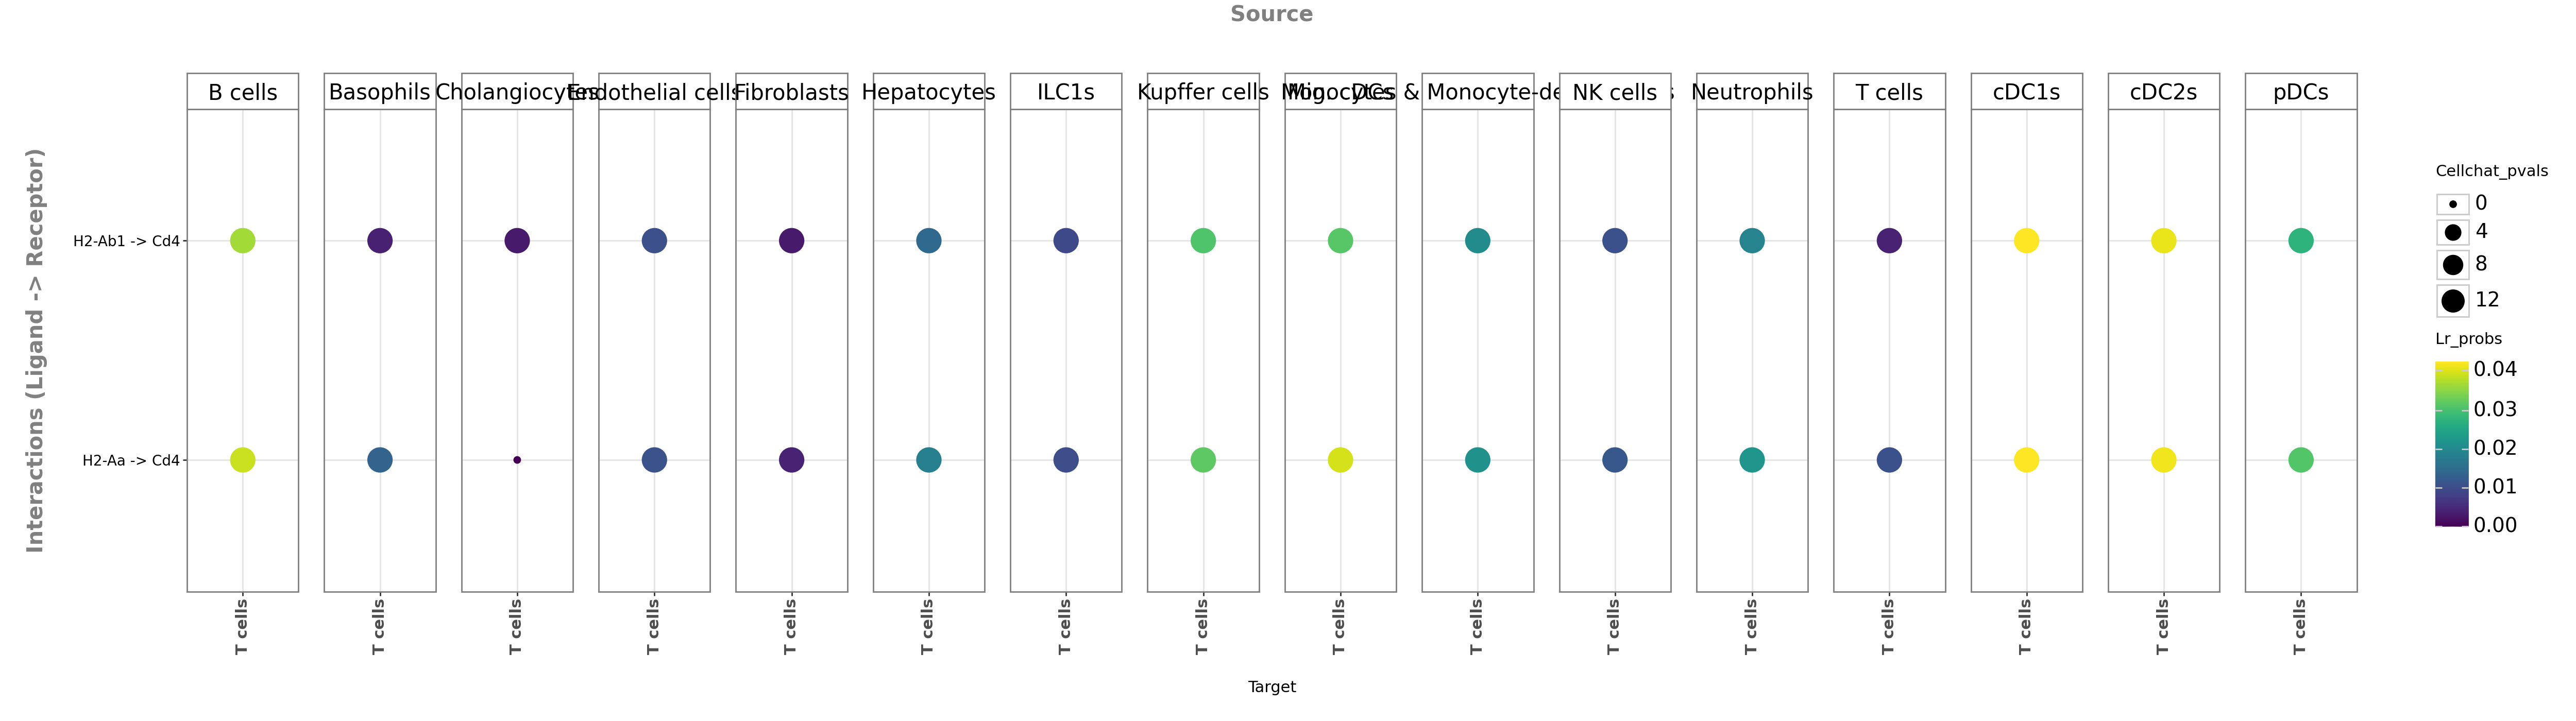

In [15]:
li.pl.dotplot(adata = adata,
              colour='lr_probs',
              size='cellchat_pvals',
              inverse_size=True, # we inverse sign since we want small p-values to have large sizes
              # source_labels=['Kupffer cells'],
              target_labels=['T cells'],
              figure_size=(25, 7),
              ligand_complex=['H2-Aa', 'H2-Ab1'],
              # finally, since cpdbv2 suggests using a filter to FPs
              # we filter the pvals column to <= 0.05
              # filter_fun=lambda x: x['cellphone_pvals'] <= 0.05,
              uns_key='cpdb_res' # uns_key to use, default is 'liana_res'
             )

In [17]:
both = x[x.ligand == ('H2-Aa' or 'H2-Ab1')]
s = sorted(both.source.unique())

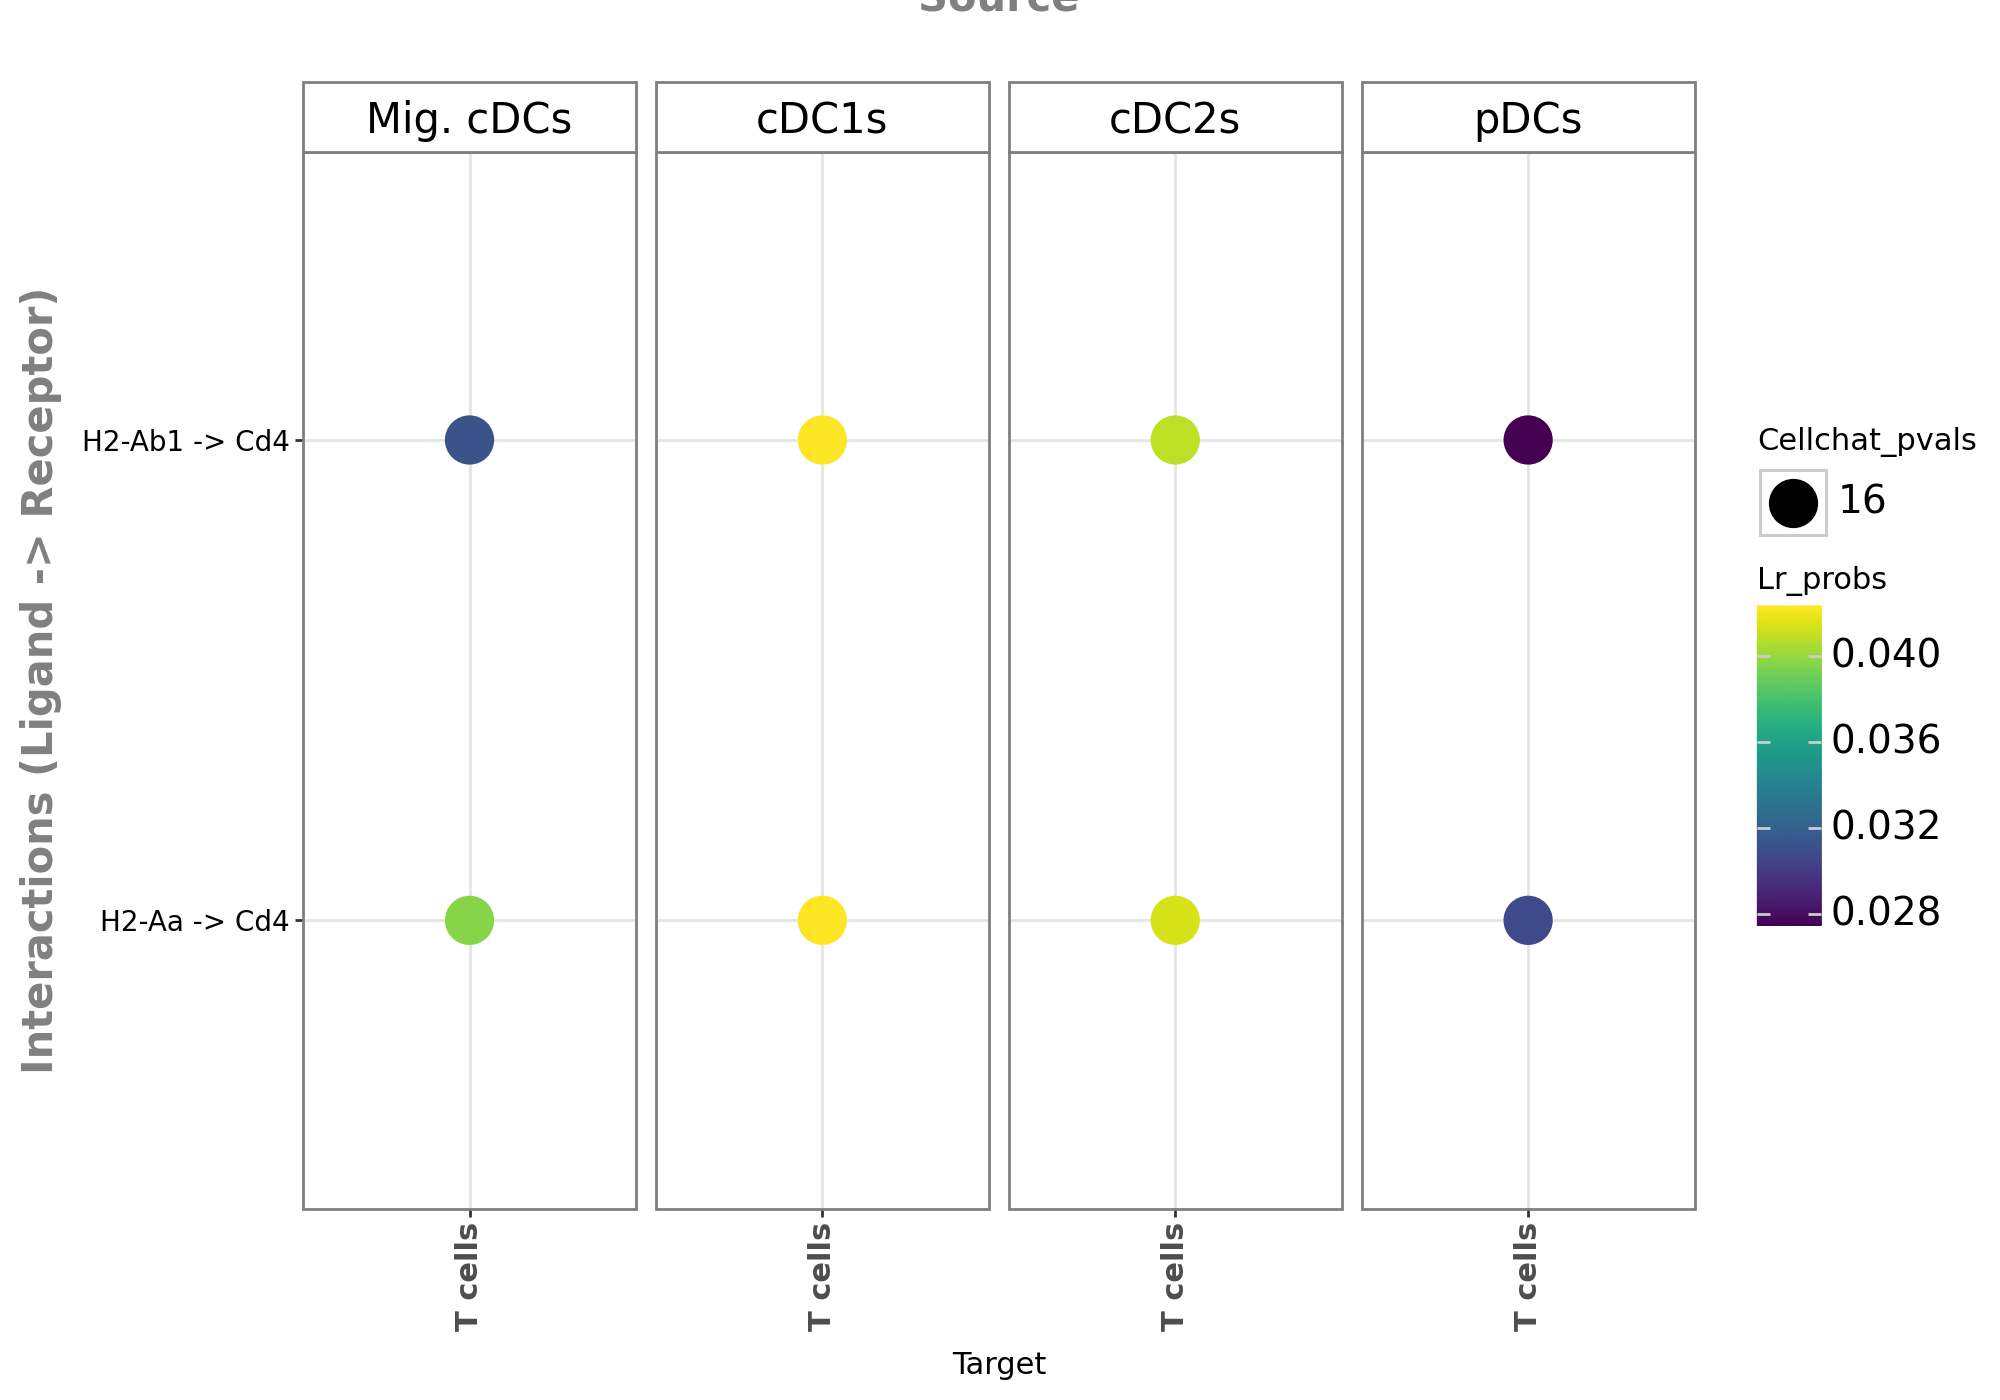

In [22]:
#only DC cells
li.pl.dotplot(adata = adata,
              colour='lr_probs',
              size='cellchat_pvals',
              inverse_size=True, # we inverse sign since we want small p-values to have large sizes
              # source_labels=['Kupffer cells'],
              source_labels=[i for i in s if "DC" in i],
              target_labels=["T cells"],
              figure_size=(10, 7),
              ligand_complex=['H2-Aa', 'H2-Ab1'],
              # finally, since cpdbv2 suggests using a filter to FPs
              # we filter the pvals column to <= 0.05
              # filter_fun=lambda x: x['cellphone_pvals'] <= 0.05,
              uns_key='cpdb_res' # uns_key to use, default is 'liana_res'
             )